# **CAREER ACCELERATOR PROJECT 2**

### **A MACHINE LEARNING, BINARY CLASSIFICATION PROJECT**

## **1. BUSINESS UNDERSTANDING**

### **Project Overview:**
The goal of this data project is to create a machine learning model that predicts customer churn for Vodafone Group. Customer churn refers to the phenomenon where customers stop using a service or product. In the context of Vodafone, it means customers leaving their mobile or telecom services.

### **Business Context:**
Vodafone Group is a global telecommunications company with millions of customers worldwide. Retaining existing customers is crucial for their business success. By predicting customer churn, Vodafone can take proactive measures to retain high-risk customers and improve overall customer satisfaction.

### **Why is predicting churn important?**
Churn prediction helps Vodafone identify customers who are likely to leave the service. By addressing their concerns or offering incentives, Vodafone can reduce churn rates and improve customer retention.

### **What data is available?**
Vodafone has access to historical customer data, including demographics, usage patterns, billing information, additional services, and more. 
The available data has the following columns.

| **Column** | **Description** |
|--------|--------------------------------------------|
| Gender | Whether the customer is a male or a female |
| SeniorCitizen | Whether a customer is a senior citizen or not |
| Partner | Whether the customer has a partner or not (Yes, No) |
| Dependents | Whether the customer has dependents or not (Yes, No) |
| Tenure | Number of months the customer has stayed with the company |
| Phone Service | Whether the customer has a phone service or not (Yes, No) |
| MultipleLines | Whether the customer has multiple lines or not |
| InternetService | Customer's internet service provider (DSL, Fiber Optic, No) |
| OnlineSecurity | Whether the customer has online security or not (Yes, No, No Internet) |
| OnlineBackup | Whether the customer has online backup or not (Yes, No, No Internet) |
| DeviceProtection | Whether the customer has device protection or not (Yes, No, No internet service) |
| TechSupport | Whether the customer has tech support or not (Yes, No, No internet) |
| StreamingTV | Whether the customer has streaming TV or not (Yes, No, No internet service) |
| StreamingMovies | Whether the customer has streaming movies or not (Yes, No, No Internet service) |
| Contract | The contract term of the customer (Month-to-Month, One year, Two year) |
| PaperlessBilling | Whether the customer has paperless billing or not (Yes, No) |
| Payment Method | The customer's payment method (Electronic check, mailed check, Bank transfer(automatic), Credit card(automatic)) |
| MonthlyCharges | The amount charged to the customer monthly |
| TotalCharges | The total amount charged to the customer |
| Churn | Whether the customer churned or not (Yes or No) |

### **Relevant features may include:**
1. Customer demographics (age, gender, etc.)
2. Usage metrics (Phone Service, Multiple Lines, etc.)
3. Billing information (monthly charges, contract type etc.)
4. Additional service interactions (Internet service, Streaming services, etc.)

### **What are the business objectives?**
1. Reduce customer churn by identifying high-risk customers early.
2. Optimize marketing efforts by targeting specific customer segments.
3. Improve customer satisfaction and loyalty.

### **How will the model be used?**
The churn prediction model will be integrated into Vodafone’s customer management system.
It will generate alerts for high-risk customers, allowing customer service representatives to take proactive actions (e.g., personalized offers, retention campaigns).

### **What are the success criteria?**
The success of the project will be evaluated based on:
**Good:** Correctly predicting churn at least 70% of the time.
**Best:** Accurately predicting churn at least 80% of the time.

### **Approach:**
1. Data Collection and Exploration:
    * Gather historical customer data from various sources.
    * Explore the data to understand its quality, completeness, and relevance.
2. Feature Engineering:
    * Create relevant features from the available data.
    * Examples: churn history, customer tenure, usage patterns, billing metrics.
3. Model Selection:
    * Choose appropriate machine learning algorithms (e.g., logistic regression, random forests).
    * Evaluate models based on performance metrics (accuracy, precision, recall).
4. Model Training and Validation:
    * Split the data to train and test data
    * Train the model on historical data.
    * Validate the model’s performance using unseen data.

### **Hypotheses:**
`Null Hypothesis (H0)`: Customer tenure does not significantly impact churn.\
`Alternative Hypothesis (H1)`: Customer tenure significantly affects churn.

### **Analytical Questions:**
1. What are the top 3 features that have strong correlation to churn?
2. What was the financial impact of customer churn on Vodafone's revenue?
3. What are the prevalent contract types and payment methods among customers exhibiting churn behavior?
4. How does the distribution of tenure differ between churned and retained customers?
5. Is there a correlation between churn and specific internet service types (e.g., fiber vs. DSL)?
6. How do different payment methods (e.g., electronic check, credit card) correlate with churn?

### **Conclusion:**
Predicting customer churn is essential for Vodafone’s business strategy. By leveraging machine learning, Vodafone can proactively address customer needs, reduce churn rates, and enhance overall customer satisfaction.

## `Data Understanding`

`Import Packages`

In [76]:
# Import packages
import numpy as np
import pandas as pd
import os
from dotenv import dotenv_values, find_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import warnings
import scipy as sp
from scipy import stats
import association_metrics as am
import openpyxl

#remove pandas display limits
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

#sklearn and machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import * 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline
import joblib

# hide warnings
warnings.filterwarnings('ignore')

print('Packages imported')


Packages imported


`Extract Datasets`

In [77]:
# Extract datasets from the database
# Load environment variables
environment_variables = dotenv_values(find_dotenv('.env'))

# Get database credentials from .env file
database = environment_variables.get('DATABASE')
server = environment_variables.get('SERVER')
username = environment_variables.get('USERNAME')
password = environment_variables.get('PASSWORD')

# Authenticate connection to the db
conn_string = f"DRIVER={{SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};MARS_Connection=yes;MinProtocolVersion=TLSv1.2;"

# Use the connect method of the pyodbc library and pass in the connection string.
# This will connect to the server and might take a few seconds to be complete. 
# Check your internet connection if it takes more time than necessary
conn = pyodbc.connect(conn_string)

print('Succeeded!')

Succeeded!


In [78]:
# Extract the first dataset from the sql server - df1
query = '''
        SELECT *
        FROM dbo.LP2_Telco_churn_first_3000
        '''
df1 = pd.read_sql_query(query, conn)
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,None,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000,False
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,56.950001,1889.500000,False
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.150002,True
3,7795-CFOCW,Male,False,False,False,45,False,None,DSL,True,False,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.750000,False
4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,False,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.649994,True


In [79]:
# Load the second dataset from a github repository - df2
df2 = pd.read_csv('https://github.com/Azubi-Africa/Career_Accelerator_LP2-Classifcation/blob/main/LP2_Telco-churn-second-2000.csv?raw=true')
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5600-PDUJF,Male,0,No,No,6,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),49.50,312.7,No
1,8292-TYSPY,Male,0,No,No,19,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Credit card (automatic),55.00,1046.5,Yes
2,0567-XRHCU,Female,0,Yes,Yes,69,No,No phone service,DSL,Yes,No,Yes,No,No,Yes,Two year,Yes,Credit card (automatic),43.95,2960.1,No
3,1867-BDVFH,Male,0,Yes,Yes,11,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.35,834.2,Yes
4,2067-QYTCF,Female,0,Yes,No,64,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,111.15,6953.4,No


In [80]:
# Combine the datasets - df = df1 + df2
df = pd.concat([df1, df2], ignore_index=True)

`Exploratory Data Analysis`

In [81]:
# Display the head of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5043 non-null   object 
 1   gender            5043 non-null   object 
 2   SeniorCitizen     5043 non-null   int64  
 3   Partner           5043 non-null   object 
 4   Dependents        5043 non-null   object 
 5   tenure            5043 non-null   int64  
 6   PhoneService      5043 non-null   object 
 7   MultipleLines     4774 non-null   object 
 8   InternetService   5043 non-null   object 
 9   OnlineSecurity    4392 non-null   object 
 10  OnlineBackup      4392 non-null   object 
 11  DeviceProtection  4392 non-null   object 
 12  TechSupport       4392 non-null   object 
 13  StreamingTV       4392 non-null   object 
 14  StreamingMovies   4392 non-null   object 
 15  Contract          5043 non-null   object 
 16  PaperlessBilling  5043 non-null   object 


* There are a total of `21` columns in the dataset
* Some columns have missing values. 

In [82]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5043.0,0.162403,0.368857,0.0,0.000,0.000000,0.000000,1.000000
tenure,5043.0,32.576641,24.529807,0.0,9.000,29.000000,56.000000,72.000000
MonthlyCharges,5043.0,65.090214,30.068133,18.4,35.775,70.550003,90.050003,118.650002


In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5043.0,0.162403,0.368857,0.0,0.000,0.000000,0.000000,1.000000
tenure,5043.0,32.576641,24.529807,0.0,9.000,29.000000,56.000000,72.000000
MonthlyCharges,5043.0,65.090214,30.068133,18.4,35.775,70.550003,90.050003,118.650002


In [85]:
df.duplicated().sum()

0

`Data Cleaning`

In [86]:
df.columns = df.columns.str.lower()

`Dealing with Missing Values`

In [87]:
#building a list of columns with nulls
nulls = []

for col in df.columns:
    if df[col].isna().sum() > 0:
        nulls.append(col)
        
nulls

['multiplelines',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'totalcharges',
 'churn']

* There are 9 columns with missing values. We will deal with them one by one. 
* The missing value in the churn column will be dropped.

In [88]:
#Checking the nulls in MultipleLines column
(df
 ['phoneservice'] #checking the relation with PhoneService column
 [df[nulls[0]].isna()] #selecting the nulls in Multiple Lines
 .unique()
 )

array([False], dtype=object)

* Notice that all missing values in Multiple Lines have PhoneService as false. 
* This is consistent with business understanding that if you don't have a phone service you can't have multiple lines.
* We will fill all missing data with False.

In [89]:
#filling the na with False
df[nulls[0]] = df[nulls[0]].fillna('False')
df[nulls[0]].isna().sum() #confirming nulls have been filled

0

In [90]:
#internet dependent services
df[df[nulls[1]].isna()] #Checking the nulls

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
11,7469-LKBCI,Male,0,False,False,16,True,False,No,None,None,None,None,None,None,Two year,False,Credit card (automatic),18.950001,326.799988,False
16,8191-XWSZG,Female,0,False,False,52,True,False,No,None,None,None,None,None,None,One year,False,Mailed check,20.650000,1022.950012,False
21,1680-VDCWW,Male,0,True,False,12,True,False,No,None,None,None,None,None,None,One year,False,Bank transfer (automatic),19.799999,202.25,False
22,1066-JKSGK,Male,0,False,False,1,True,False,No,None,None,None,None,None,None,Month-to-month,False,Mailed check,20.150000,20.15,True
33,7310-EGVHZ,Male,0,False,False,1,True,False,No,None,None,None,None,None,None,Month-to-month,False,Bank transfer (automatic),20.200001,20.200001,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2984,6765-MBQNU,Female,0,True,False,26,True,True,No,None,None,None,None,None,None,One year,False,Mailed check,26.000000,684.049988,False
2987,3769-MHZNV,Female,0,True,True,33,True,False,No,None,None,None,None,None,None,Two year,False,Mailed check,20.100000,670.349976,False
2989,3308-MHOOC,Male,0,False,True,1,True,False,No,None,None,None,None,None,None,Month-to-month,True,Mailed check,19.200001,19.200001,False
2993,2239-CFOUJ,Male,0,True,True,1,True,False,No,None,None,None,None,None,None,One year,False,Mailed check,20.400000,20.4,False


In [91]:
(df
 ['internetservice'] #checking the relation with InternetService column
 [df[nulls[6]].isna()] #selecting the nulls in Multiple Lines
 .unique()
 )

array(['No'], dtype=object)

* Note that all the columns in `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,`StreamingTV`, `StreamingMovies` are internet services and are dependent on the `InternetService` column. 
* All of them have `651` missing values which gives credence to our assumption.
* All the ones with `No` in the `InternetService` column have been filled with No internet service. This is how we will fill our nulls.

In [92]:
#loop to fill all na in the columns with No internet service
for col in nulls[1:7]:
    if df['internetservice'][df[col].isna()].unique() == 'No': #Condition to check for No in InternetService column
        df[col] = df[col].fillna('No internet service')

In [93]:
#confirming all nulls have been filled
df[nulls[1:7]].isna().sum()

onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
dtype: int64

In [94]:
#viewing the missing values in the Total charges column
df[df[nulls[7]].isna()] 

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,True,True,0,False,False,DSL,True,False,True,True,True,False,Two year,True,Bank transfer (automatic),52.549999,NaN,False
753,3115-CZMZD,Male,0,False,True,0,True,False,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.250000,NaN,False
936,5709-LVOEQ,Female,0,True,True,0,True,False,DSL,True,True,True,False,True,True,Two year,False,Mailed check,80.849998,NaN,False
1082,4367-NUYAO,Male,0,True,True,0,True,True,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.750000,NaN,False
1340,1371-DWPAZ,Female,0,True,True,0,False,False,DSL,True,True,True,True,True,False,Two year,False,Credit card (automatic),56.049999,NaN,False


* The missing total charge values have `0` tenure.
* We will assume it is because the tenure has not reached the 1 month threshold yet and fill them with the Monthly charge. 

In [95]:
#Filling the Nulls in Total Charges with MonthlyCharge value
df[nulls[-2]]=(df
                 [nulls[-2]] #Select the TotalCharges Column
                 .fillna(df
                         ['monthlycharges'] #Select the Monthlycharges
                         [df[nulls[-2]].isna()] #Filter with the TotalCharges that are null
                         )
                 )

In [96]:
df[nulls[-2]].isna().sum() #confirming nulls have been filled

0

In [97]:
#dropping the Null in Churn column
df = df.dropna()
df[nulls[-1]].isna().sum() #confirming null has been dropped

0

In [98]:
#confirming all missing values have been dealt with
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

`Dealing with Datatypes`

In [99]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [100]:
#list of categorical columns
categorical = ['gender','seniorcitizen', 'partner','dependents','phoneservice', 'multiplelines', 'internetservice','onlinesecurity','onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies','contract','paperlessbilling','paymentmethod','churn']

In [101]:
#list of numeric columns
numeric = ['tenure','monthlycharges','totalcharges']

In [102]:
#converting totalcharges to numeric
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [103]:
#confirming all columns are in expected datatypes
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [104]:
#setting customer ID as index
df = df.set_index(keys = 'customerid')

In [105]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,5042,2,Male,2558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniorcitizen,5042.0,NaN,NaN,NaN,0.162436,0.368886,0.0,0.0,0.0,0.0,1.0
partner,5042,4,False,1538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,5042,4,False,2069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,5042.0,NaN,NaN,NaN,32.568822,24.525954,0.0,9.0,29.0,56.0,72.0
phoneservice,5042,4,True,2730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines,5042,6,False,1437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice,5042,3,Fiber optic,2247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinesecurity,5042,5,False,1478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinebackup,5042,5,False,1320,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* There are varying number of unique values in the categorical columns. We expected `2` and `3`. 
* The numeric columns all show a variance between the mean and median which implies the data may not be normally distributed.

In [106]:
#checking all unique values in the categorical columns
categories = pd.Series({c: df[c].unique() for c in df[categorical]})
pd.DataFrame(categories)

,0
gender,"[Female, Male]"
seniorcitizen,"[0, 1]"
partner,"[True, False, No, Yes]"
dependents,"[False, True, No, Yes]"
phoneservice,"[False, True, Yes, No]"
multiplelines,"[False, False, True, No, No phone service, Yes]"
internetservice,"[DSL, Fiber optic, No]"
onlinesecurity,"[False, True, No internet service, No, Yes]"
onlinebackup,"[True, False, No internet service, No, Yes]"
deviceprotection,"[False, True, No internet service, No, Yes]"


* Some of the columns have different names for the categories such as `False` and `No` or `True` and `Yes` even though they mean the same thing. 
* We will combine them to only `Yes` and `No`

In [107]:
# no = ['False','No','No internet service','No phone service']
# yes = ['True', 'Yes']

In [108]:
no = ['False','No','No internet service','No phone service']
yes = ['True', 'Yes']

def replace_with_yes_no(tmp_df):
    """
    Replaces unique values in a DataFrame column with 'Yes' or 'No' based on the provided lists.
    
    Args:
        tmp_df (pd.DataFrame): The DataFrame containing the columns to be processed.
    
    Returns:
        pd.DataFrame: The modified DataFrame with replaced values.
    """
    # Create a mapping dictionary
    mapping = {value: 'Yes' for value in yes}
    mapping.update({value: 'No' for value in no})

    # Apply the mapping to each column
    for column_name in tmp_df.columns:
        tmp_df[column_name] = tmp_df[column_name].map(mapping).fillna(tmp_df[column_name])
    
    return tmp_df

In [109]:
#replacing the categorical columns with the 
df[categorical] = replace_with_yes_no(df[categorical])
df[categorical]

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
customerid,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,True,False,False,No,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,False
5575-GNVDE,Male,0,False,False,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,False
3668-QPYBK,Male,0,False,False,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,True
7795-CFOCW,Male,0,False,False,False,No,DSL,True,False,True,True,False,False,One year,False,Bank transfer (automatic),False
9237-HQITU,Female,0,False,False,True,False,Fiber optic,False,False,False,False,False,False,Month-to-month,True,Electronic check,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
4801-JZAZL,Female,0,Yes,Yes,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No


In [110]:
df[categorical].describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,5042,2,Male,2558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniorcitizen,5042.0,NaN,NaN,NaN,0.162436,0.368886,0.0,0.0,0.0,0.0,1.0
partner,5042,4,False,1538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,5042,4,False,2069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phoneservice,5042,4,True,2730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines,5042,4,No,1476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice,5042,3,Fiber optic,2247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinesecurity,5042,4,No,2109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinebackup,5042,4,No,1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deviceprotection,5042,4,No,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
#changing all categorical columns to category datatype
df[categorical] = df[categorical].astype('category')
df.dtypes

gender              category
seniorcitizen       category
partner             category
dependents          category
tenure                 int64
phoneservice        category
multiplelines       category
internetservice     category
onlinesecurity      category
onlinebackup        category
deviceprotection    category
techsupport         category
streamingtv         category
streamingmovies     category
contract            category
paperlessbilling    category
paymentmethod       category
monthlycharges       float64
totalcharges         float64
churn               category
dtype: object

In [112]:
#writing out clean dataset
df.to_csv('../Data/Cleaned_Dataset.csv')

`STATISTICAL ANALYSIS`

`Univariate Analysis`

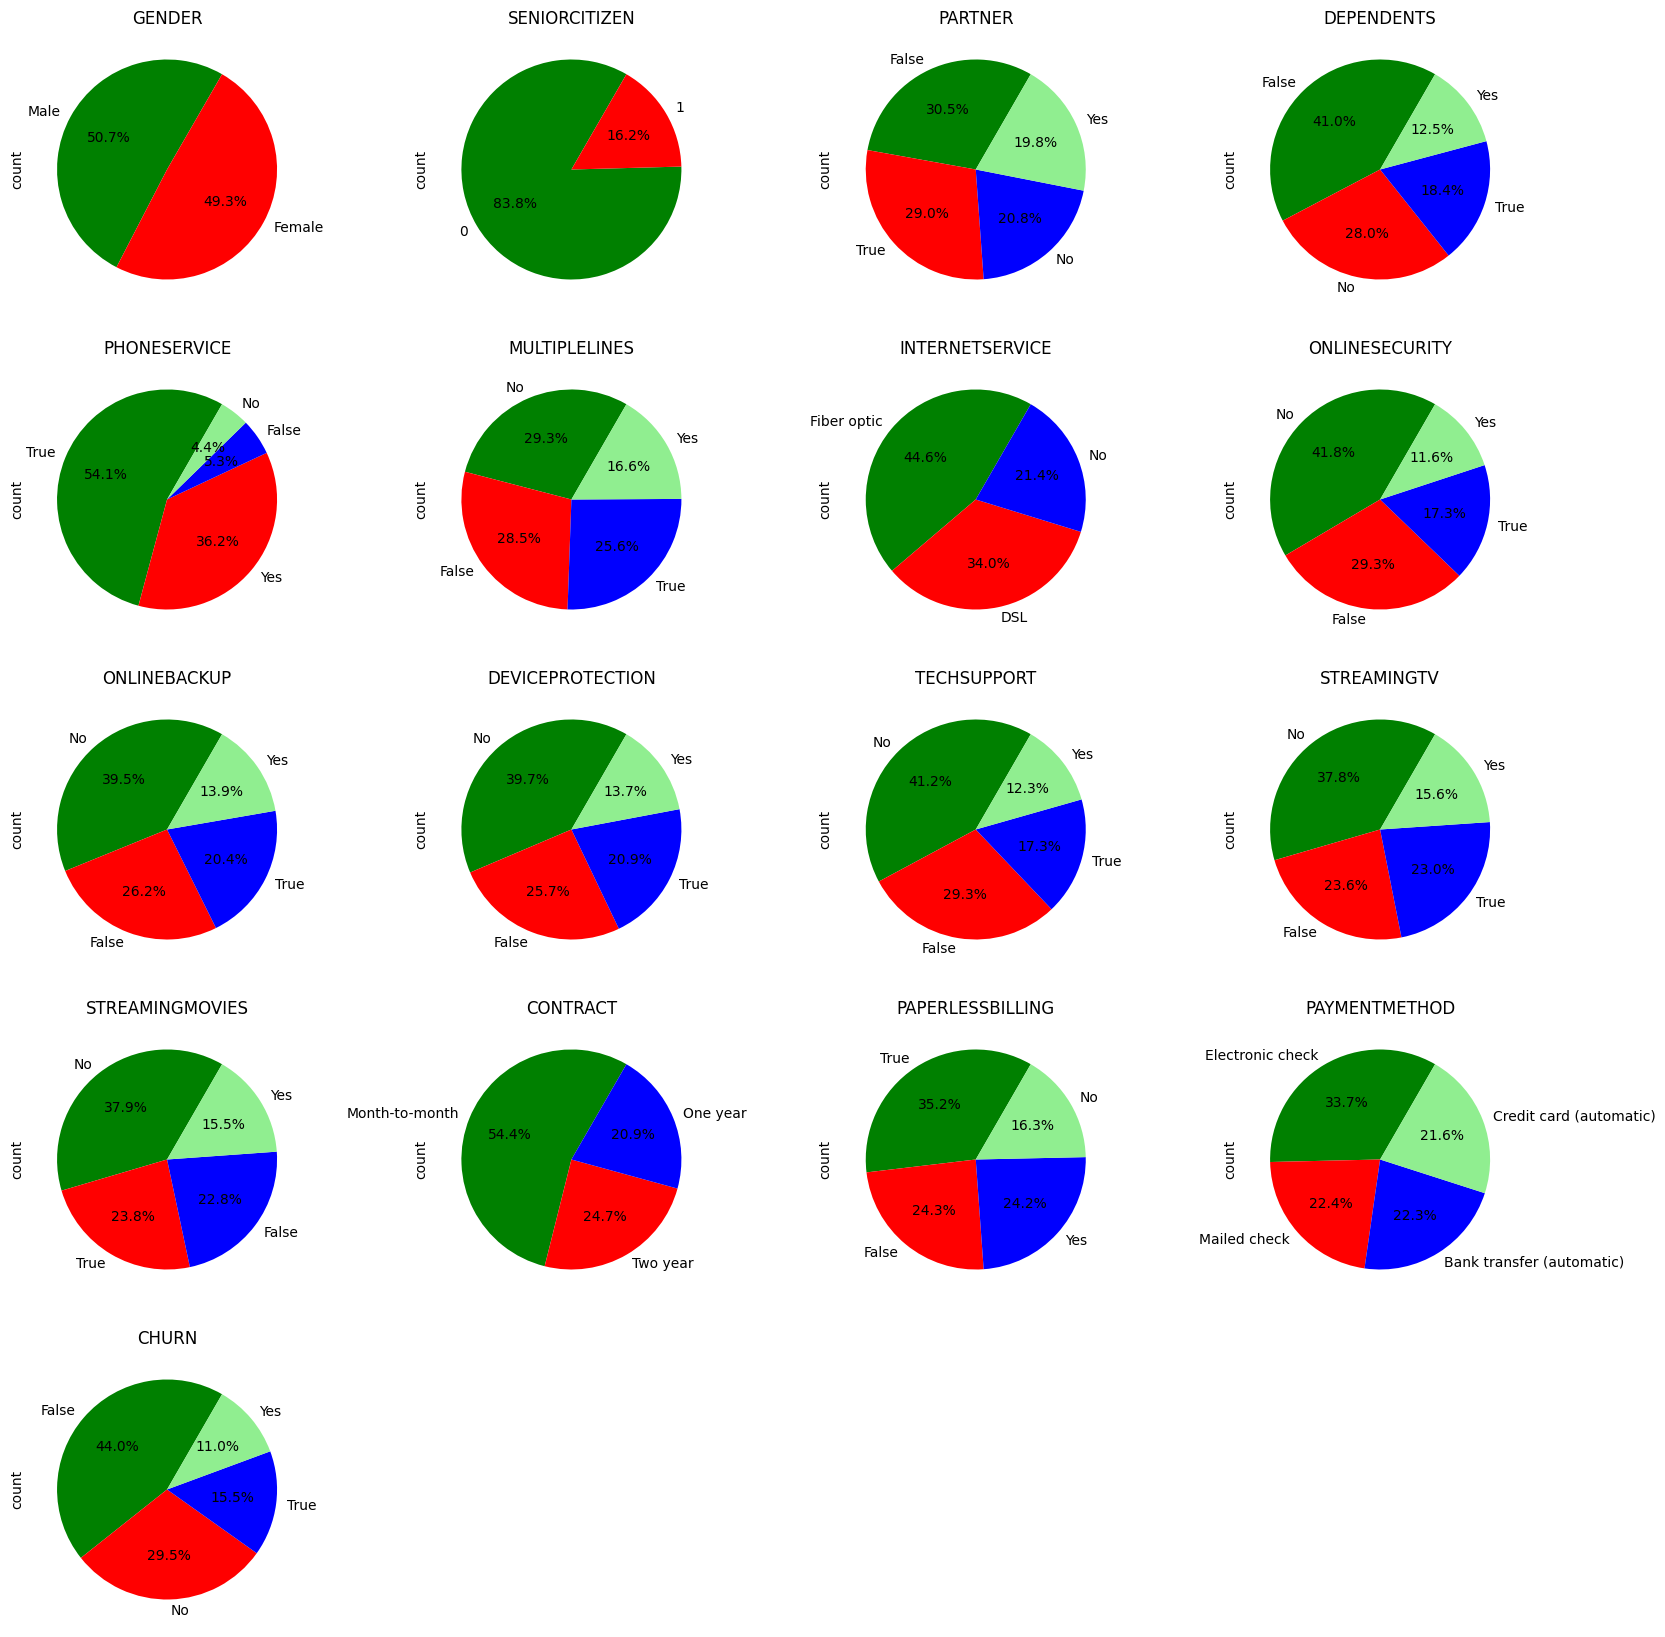

In [113]:
for i, var in enumerate(categorical):
    plt.subplot(round(len(categorical)/3), 4, i+1)
    df[var].value_counts().plot.pie(fontsize=10, figsize=(20,25), autopct="%2.1f%%", startangle=60, colors=['green','red','blue','lightgreen'])
    plt.title(f'{var.upper()}')

**Key observations**
1. `50.7%` of the customers are male.
2. `16.2%` of the customers are senior citizens.
3. `51.3%` of customers do not have partners.
4. `69.0%` of the customers have dependents.
5. `90.3%` of the customers have a phone service. 
6. Of the customers with a phone service, `57.8%` have Multiple Lines.
7. `78.6%` of the customers have Internet service. `44.6%` of them have Fiber and `34.0%` have a DSL connection.
8. The customers who have internet service, `71.1%` have Online Security, `65.7%` have Online Backup, `65.4%` have Device Protection, `70.4%` have Tech Support, `61.4%` have Movie Tv Streaming and `60.7%` have Movie Streaming.
9. `54.4%` of the customers have month-to-month contracts, while `20.9%` and `24.7%` have One Year and Two Year contracts respectively.
10. `59.4%` of customers use paperless billing.
11. The highest percentage of customer pay via Electronic check at `33.7%`, followed by Mailed Check, Bank transfer and Credit transfer at `22.4%`, `22.3%` and `21.6%` respectively.
12. The proportion of customers recorded to have churned is `26.5%`. The company has a retention of `73.5%`

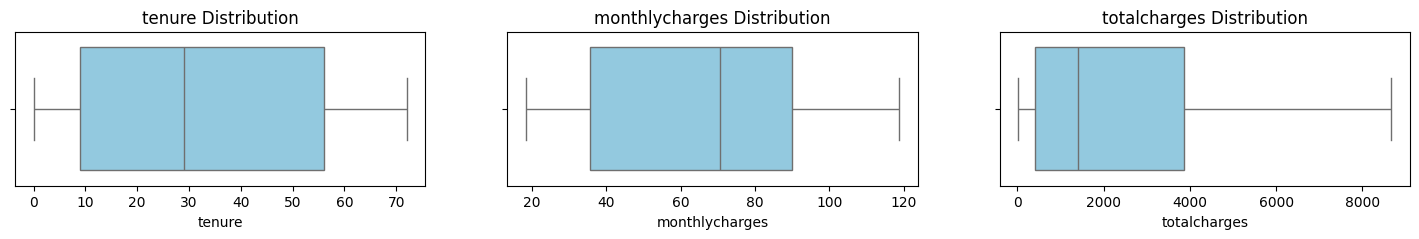

In [114]:
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(18,2)) #create subplot framework
for i, col in enumerate(numeric):
    plt.subplot(1,3,i+1)
    sns.boxplot(df[col], color='skyblue', orient='h')
    plt.title(f'{col} Distribution')

**Key Observations**
1. There are no outliers in the numeric columns
2. All numeric columns have some level of skewness and are not normally distributed.


`Bivariate Analysis`

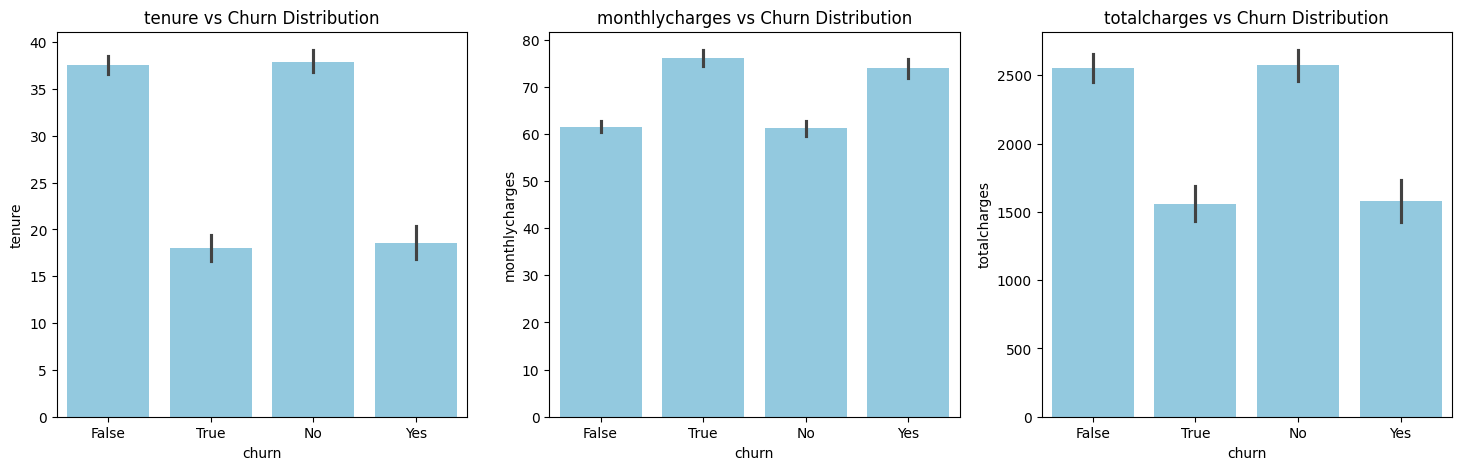

In [115]:
#checking distribution of numeric data across churned and unchurned customers
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(18,5))
for i, col in enumerate(numeric):
    plt.subplot(1,3,i+1)
    sns.barplot(data=df, x='churn', y=col, color='skyblue')
    plt.title(f'{col} vs Churn Distribution')

The Pairplot provides the insight below;
* `TotalCharges` has strong correlation with `tenure` and `MonthlyCharges`.
* `MonthlyCharges` has slight correlation with `tenure`.

`Multivariate Analysis`

NameError: name 'num_cols' is not defined

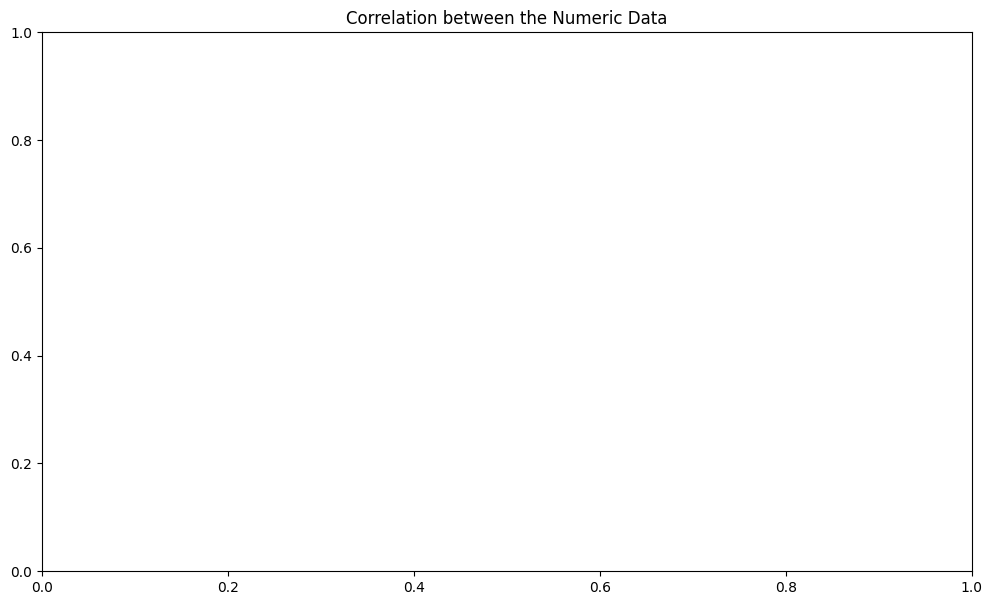

In [116]:
plt.figure(figsize=(12, 7))
plt.title('Correlation between the Numeric Data')
sns.heatmap(data=df[num_cols].corr(), annot = True, vmin = -1, vmax = 1)
plt.show()

The heatmap provides the insight below;
* `TotalCharges` has strong correlation with `tenure`.
* There is a decent correlation between `TotalCharges` and `MonthlyCharges`
* `MonthlyCharges` has little correlation with `tenure`.



`Answering the Analytical Questions`

*Question 1 -* What are the top 3 features that have strong correlation to churn?

In [ ]:
# # Mapping Churn Values to numeric
# df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
# df.drop('customerID', axis=1, inplace=True)

In [ ]:
# #  Make dummy variables for all categorical
# dfd = pd.get_dummies(df)
# # dfd.tail()

In [ ]:
# # Correlation plot
# plt.figure(figsize=(10, 10))
# dfd.corr()['Churn'].sort_values(ascending=False).plot(kind='bar');

After calculating the correlation coefficients between the 'churn' variable and all other features in the dataset, we found that the following features exhibit the strongest correlations with churn:

* `Contract` (correlation coefficient: 0.411764)
* `InternetService` (correlation coefficient: 0.320970)
* `PaymentMethod` (correlation coefficient: 0.292181)

These top 3 features show the highest correlation with churn, indicating that they may play a significant role in predicting or influencing customer churn behavior.

**Question 2 -** How does the presence of online security, backup, and tech support affect churn?

In [ ]:
# count of churners and non-churners for each combination of features

churn_counts = df.groupby(['OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Churn']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(10, 6))
churn_counts.plot(kind='bar', stacked=True, color=['red', 'green'], ax=plt.gca())
plt.title('Churn Status by Presence of OnlineSecurity, OnlineBackup, and TechSupport')
plt.xlabel('OnlineSecurity, OnlineBackup, and TechSupport')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Among customers who do not have online security, online backup, and tech support, the churn rate is higher compared to customers who have these services. Approximately 47.6% of customers without these services churned, while only 40.3% of customers with these services churned.
This suggests that the presence of online security, online backup, and tech support may have a beneficial effect on reducing churn. Customers who have access to these services are less likely to churn compared to those who do not have these services.
Therefore, the business may consider investing in or improving online security, online backup, and tech support services as part of their churn reduction strategy. Providing these services could potentially increase customer satisfaction and loyalty, leading to lower churn rates and higher retention of customers.

**Question 3 -** What was the financial impact of customer churn on Vodafone's revenue?

In [ ]:
# #Comparing revenue for churned and retained customers
# retained_revenue = (df['TotalCharges'].where(df['Churn']== 0).sum())

# lost_revenue = (df['TotalCharges'].where(df['Churn'] == 1).sum())

# churnimpact=[retained_revenue, lost_revenue]
# churnimpact
# plt.figure(figsize=(7,7))
# plt.pie(colors=['green','red'], startangle=90, x=churnimpact, explode=[0.05,0.05], autopct='%2.2f%%', labels=['Retained','Lost'])
# plt.title(f'Impact of Customer Churn on Revenue')
# plt.show()


Customer Churn results in a loss of USD 2,092,874.25 in Revenue for the company

**Question 4 -** What are the prevalent contract types and payment methods among customers exhibiting churn behavior?

In [ ]:
contract_churn = df['Contract'].where(df['Churn'] ==1).value_counts()

data = pd.DataFrame({'Churned':contract_churn, 'Overall':df['Contract'].value_counts()}).T
for i,col in enumerate(data):
    plt.subplot(1,3,i+1)
    data[col].plot(kind='pie', autopct = '%2.2f%%', explode=[0,0.1], startangle=50, figsize=(15,10), colors=['red','green'])

In [ ]:
payment_churn = df['PaymentMethod'].where(df['Churn'] ==1).value_counts()

data = pd.DataFrame({'Churned':payment_churn, 'Overall':df['PaymentMethod'].value_counts()}).T
for i,col in enumerate(data):
    plt.subplot(1,4,i+1)
    data[col].plot(kind='pie', autopct = '%2.2f%%', explode=[0,0.1], startangle=50, figsize=(15,10), colors=['red','green'])

- The Month to month contract is the most prevalent contract type with 30.14% of the customers having churned.
- The Electronic check method is the most prevalent PaymentMethod type with 30.85% of the customers having churned.


**Question 5 -** How does the distribution of tenure differ between churned and retained customers?

In [ ]:
#checking distribution of tenure for retained and churned customers
churned_tenure = (df['tenure'].where(df['Churn'] == "Yes").value_counts())

retained_tenure = (df['tenure'].where(df['Churn'] == "No").value_counts())

data = pd.DataFrame({'Churned':churned_tenure,'Retained':retained_tenure})

data.plot(kind='kde', figsize=(10,5));

`Hypothesis Testing`

In [ ]:
# Creating contingency table
contingency_table = pd.crosstab(df['tenure'], df['Churn'])
# print("Contingency Table:")
# print(contingency_table)

# Chi-Square Test
observed = contingency_table.values
chi2, p, dof, expected = stats.chi2_contingency(observed)
# print("\nExpected Frequencies:")
# print(expected)

print("\nChi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

# Interpretation
alpha = 0.05
print("\nSignificance Level (alpha):", alpha)
if p < alpha:
    print("Reject Null Hypothesis: There is a significant relationship between tenure and churn.")
else:
    print("Fail to Reject Null Hypothesis: There is no significant relationship between tenure and churn.")

It is evident from the above that `the duration of a customer's tenure with Vodafone does not exhibits a noticeable relationship with their probability of churning.`

## `Data Preprocessing`

In [ ]:
#Splitting data
#Use Stratified Test Split
X = df.drop(columns= ['Churn'])
y = df['Churn']
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Encoding target variable
encoder = LabelEncoder()

#fitting y_train and y_eval
y_train_encoded = encoder.fit_transform(y_train)
y_eval_encoded = encoder.transform(y_eval)

In [ ]:
#Checking Dtypes
X.dtypes

In [ ]:
#List of numeric Columns
numerical = X.select_dtypes('number').columns
categoric = X.select_dtypes('Category').columns


In [ ]:
categoric

`Pipeline Build`

In [ ]:
# Set up the transformers
# For the numeric variables
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), # handlie missing values
                                      ("scaler", MinMaxScaler()) # scale numerics
                                     ]
                              )
# For the categorical variables
categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(sparse_output=False)),
                                       ("imputer", SimpleImputer(strategy="most_frequent"))
                                      ]
                               )
# Set up the final preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[("numeric", numeric_transformer, numerical),
                                                     ("categorical", categorical_transformer, categoric)
                                                    ]
                                      )
preprocessor

In [ ]:
#Checking if data is balanced
y_train.value_counts()

In [ ]:
#checking data balance
plt.pie(x=y_train.value_counts(),autopct='%2.2f%%', colors=['red','lightgreen'], startangle=90, explode=[0.1,0.05])
plt.title('Balance of datapoints in target variable (Churn)')
plt.legend(labels=['No','Yes'])
plt.show()

`Observation`

The data exhibits a significant imbalance, with a ratio of 73.45% for "No" and 26.55% for "Yes."


`Action`

We'll initially train on an unbalanced dataset and subsequently assess performance by comparing it with a balanced dataset.



## `Model and Evaluation`

In [ ]:
#Building Model List
models = [('RandomForest', RandomForestClassifier(random_state=42)), 
          ('LogisticRegression',LogisticRegression(random_state=42)),
          ('AdaBoost',AdaBoostClassifier(random_state=42, n_estimators=67)),
          ('XGB', XGBClassifier(random_state = 42, verbose = False, n_jobs = -1)),
          ('DecisionTree', DecisionTreeClassifier(random_state= 42)),
          ('KNN',KNeighborsClassifier(n_neighbors=7))
          ]

`Training and Evaluation of Unbalanced Data`

In [ ]:
#create a dictionary to host all the trained models
all_pipelines = {}

#Create a dataframe of the evaluation metrics
metrics_df = pd.DataFrame(columns=['model','precision','recall','f1_score'])

#Create a dataframe for confusion matrices
confusion_df = pd.DataFrame(columns=['model','matrix'])

#loop over models in model list
for model_name,classifier in models:
    #create final pipeline for training
    final_pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',classifier)
    ])
    
    #fitting data to pipeline
    final_pipeline.fit(X_train,y_train_encoded)
    
    #adding to dictionary
    all_pipelines[model_name] = final_pipeline
    
    #perform prediction
    y_pred = final_pipeline.predict(X_eval)
    
    #calculate evaluation metrics
    metrics = classification_report(y_eval_encoded,y_pred, output_dict=True,)
    
    #define the columns to add to the table
    model = model_name
    precision = metrics['weighted avg']['precision']
    recall = metrics['weighted avg']['recall']
    f1_score = metrics['weighted avg']['f1-score']
    
    #append evaluation metrics to dataframe
    metrics_df.loc[len(metrics_df)] = [model,precision,recall,f1_score]
    
    #plot the confusion matrix
    pipeline_conf_dict = {}
    
    # Define the Confusion Matrix
    model_conf_mat = confusion_matrix(y_eval_encoded, y_pred)
    
    #append confusion matrix to dictionary
    pipeline_conf_dict[model_name] = pd.DataFrame(model_conf_mat)
    
    #append to confusion dataframe
    confusion_df.loc[len(confusion_df)] = [model_name,pd.DataFrame(model_conf_mat)]
     
#set index   
confusion_df = confusion_df.set_index('model')

metrics_df.sort_values('f1_score', ascending=False)

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop through trained models to plot confusion matrix
for i, (model, matrix) in enumerate(zip(metrics_df['model'], confusion_df['matrix'])):
    sns.heatmap(matrix, annot=True, cmap='RdPu', fmt='2.0f', ax=axs[i//3, i%3])
    axs[i//3, i%3].set_title(f'{model} Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Create a dictionary for the ROC AUC scores
roc_auc_df = {}

fig, ax = plt.subplots(figsize=(8, 8))

for model, pipeline in all_pipelines.items():
    # Calculate prediction probabilities for the ROC AUC curve
    y_score = pipeline.predict_proba(X_eval)[:, 1]

    # Calculate ROC AUC
    fpr, tpr, threshold = roc_curve(y_eval_encoded, y_score)
    auc_score = auc(fpr, tpr)

    # Create a DataFrame for ROC AUC data
    roc_auc_dict = pd.DataFrame({'FalsePositiveRate': fpr, 'TruePositiveRate': tpr, 'Threshold': threshold})
    
    # Append DataFrame to dictionary
    roc_auc_df[model] = roc_auc_dict
    
    # Plot ROC AUC curve
    ax.plot(fpr, tpr, label=f'{model} (AUC={auc_score})')
    
ax.set_xlabel('True Positive Rate')
ax.set_ylabel('False Positive Rate')

plt.legend(loc='lower right')
plt.title('ROC AUC Curve')
plt.show()


**Findings**

Analysis of the unbalanced data reveals the following insights:

`AdaBoost` emerges as the top performer, boasting an impressive AUC score of `83.23%` and an f1_score of `78.89%`.
Following closely, `Logistics Regression` and `XGBoost` secure the 2nd and 3rd positions, achieving AUC scores of `81.60%` and `78.0%`, with corresponding f1_scores of `78.08%` and `74.76%` respectively.

`Training on Balanced Dataset - SMOTE Oversampling`

In [ ]:
#create a dictionary to host all the trained models
all_balanced_pipelines = {}

#Create a dataframe of the evaluation metrics
balanced_metrics_df = pd.DataFrame(columns=['model','precision','recall','f1_score'])

#Create a dataframe for confusion matrices
balanced_confusion_df = pd.DataFrame(columns=['model','matrix'])

#loop over models in model list
for model_name,classifier in models:
    #create final pipeline for training
    balanced_pipeline = imbPipeline(steps=[
        ('preprocessor',preprocessor),
        ('smote_sampler',SMOTE(random_state=42)),
        ('classifier',classifier)
    ])
    
    #fitting data to pipeline
    balanced_pipeline.fit(X_train,y_train_encoded)
    
    #adding to dictionary
    all_balanced_pipelines[model_name] = balanced_pipeline
    
    #perform prediction
    y_pred = balanced_pipeline.predict(X_eval)
    
    #calculate evaluation metrics ()
    balanced_metrics = classification_report(y_eval_encoded,y_pred, output_dict=True,)
    
    #define the columns to add to the table
    model = model_name
    precision = balanced_metrics['weighted avg']['precision']
    recall = balanced_metrics['weighted avg']['recall']
    f1_score = balanced_metrics['weighted avg']['f1-score']
    
    #append evaluation metrics to dataframe
    balanced_metrics_df.loc[len(balanced_metrics_df)] = [model,precision,recall,f1_score]
    
    #create an empty dictionary for the confusion matrices
    balanced_pipeline_conf_dict = {}
    
    # Define the Confusion Matrix
    balanced_model_conf_mat = confusion_matrix(y_eval_encoded, y_pred)
    
    #append confusion matrix to dictionary
    balanced_pipeline_conf_dict[model_name] = pd.DataFrame(balanced_model_conf_mat)
    
    #append to confusion dataframe
    balanced_confusion_df.loc[len(balanced_confusion_df)] = [model_name,pd.DataFrame(balanced_model_conf_mat)]
     
#balanced_metrics_df
#set index   
balanced_confusion_df = balanced_confusion_df.set_index('model')

balanced_metrics_df.sort_values('f1_score', ascending=False)

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop through trained models to plot confusion matrix
for i, model in enumerate(balanced_metrics_df['model']):
    ax = axs[i // 3, i % 3]  # Get the appropriate subplot
    sns.heatmap(balanced_confusion_df['matrix'][model], annot=True, cmap='RdPu', fmt='2.0f', ax=ax)
    ax.set_title(f'{model} Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Create a dictionary to store the ROC AUC scores
balanced_roc_auc_df = {}

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Iterate through each model and its corresponding pipeline
for model, pipeline in all_balanced_pipelines.items():
    # Predict probabilities for the ROC AUC curve
    y_score = pipeline.predict_proba(X_eval)[:, 1]

    # Compute ROC curve and ROC AUC
    fpr, tpr, threshold = roc_curve(y_eval_encoded, y_score)
    auc_score = auc(fpr, tpr)

    # Store the results in a DataFrame and add it to the dictionary
    balanced_roc_auc_dict = pd.DataFrame({'FalsePositiveRate': fpr, 'TruePositiveRate': tpr, 'Threshold': threshold})
    balanced_roc_auc_df[model] = balanced_roc_auc_dict

    # Plot the ROC curve for the current model
    ax.plot(fpr, tpr, label=f'{model} (AUC={auc_score})')

# Set labels and title
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC AUC Curve')

# Display the plot
plt.show()


**Observations**
- **When using data balanced by Oversampling (SMOTE), we can observe the following:**

With unbalanced data, the model with the best F1 Score also had the best AUC Score. However, with the SMOTE oversampled dataset, this is not the case.

`AdaBoost` has the highest AUC score at `83.17%`, followed by `Logistic Regression` and `XGBoost` at `81.31`% and `79.01%`, respectively.

`Logistic Regression` has the highest F1 score at `74.54%`, followed by AdaBoost and XGBoost at `74.41%` and `73.23%`, respectively.

Examining the Confusion Matrices, the models perform better in predicting true positives when the data is balanced compared to when it's imbalanced. The top performers in this regard are `Logistic Regression`, followed by `AdaBoost` and `KNN`.

`Training on Balanced (Weighting) Dataset`

In [ ]:
#Building weighted Model List
weighted_models = [('RandomForest', RandomForestClassifier(random_state=42, class_weight="balanced")), 
          ('LogisticRegression',LogisticRegression(random_state=42, class_weight="balanced")),
         #('AdaBoost',AdaBoostClassifier(random_state=42, n_estimators=67 )),
         #('XGB', XGBClassifier(random_state = 42, verbose = False, n_jobs = -1)),
          ('DecisionTree', DecisionTreeClassifier(random_state= 42, class_weight="balanced"))
         #('KNN',KNeighborsClassifier(n_neighbors=7,))
]

#Boosted Models work in a way that does not need weighting
#checking if performance of balanced models is better than unweighted models

In [ ]:
#create a dictionary to host all the trained models
all_weighted_pipelines = {}

#Create a dataframe of the evaluation metrics
weighted_metrics_df = pd.DataFrame(columns=['model','precision','recall','f1_score'])

#Create a dataframe for confusion matrices
weighted_confusion_df = pd.DataFrame(columns=['model','matrix'])

#loop over models in model list
for model_name,classifier in weighted_models:
    #if model_name != 'RandomForest':
    #create final pipeline for training
    weighted_pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        #('smote_sampler',SMOTE(random_state=42)),
        ('classifier',classifier)
    ])
    
    #fitting data to pipeline
    weighted_pipeline.fit(X_train,y_train_encoded)
    
    #adding to dictionary
    all_weighted_pipelines[model_name] = weighted_pipeline
    
    #perform prediction
    y_pred = weighted_pipeline.predict(X_eval)
    
    #calculate evaluation metrics ()
    weighted_metrics = classification_report(y_eval_encoded,y_pred, output_dict=True,)
    
    #define the columns to add to the table
    model = model_name
    precision = weighted_metrics['weighted avg']['precision']
    recall = weighted_metrics['weighted avg']['recall']
    f1_score = weighted_metrics['weighted avg']['f1-score']
    
    #append evaluation metrics to dataframe
    weighted_metrics_df.loc[len(weighted_metrics_df)] = [model,precision,recall,f1_score]
    
    #create an empty dictionary for the confusion matrices
    weighted_pipeline_conf_dict = {}
    
    # Define the Confusion Matrix
    weighted_model_conf_mat = confusion_matrix(y_eval_encoded, y_pred)
    
    #append confusion matrix to dictionary
    weighted_pipeline_conf_dict[model_name] = pd.DataFrame(weighted_model_conf_mat)
    
    #append to confusion dataframe
    weighted_confusion_df.loc[len(weighted_confusion_df)] = [model_name,pd.DataFrame(weighted_model_conf_mat)]
     
#balanced_metrics_df
#set index   
weighted_confusion_df = weighted_confusion_df.set_index('model')

weighted_metrics_df.sort_values('f1_score', ascending=False)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
#Loop through trained models to plot confusion matrix
for i, model in enumerate(weighted_metrics_df['model']):
    plt.subplot(1,3,i+1)
    sns.heatmap(weighted_confusion_df['matrix'][model], annot=True, cmap='RdPu', fmt='2.0f')
    plt.title(f'{model} Confusion Matrix')
plt.show()

In [ ]:
#Create a dctionary for the ROC AUC scores
weighted_roc_auc_df = {}

fig, ax = plt.subplots(figsize=(8,8))

for model,pipeline in all_weighted_pipelines.items():
    #calculate prediction probabilities for the ROC AUC curve
    y_score = pipeline.predict_proba(X_eval)[:,1]

    #calculate ROC AUC
    fpr, tpr, threshold = roc_curve(y_eval_encoded,y_score)
    auc_score = auc(fpr,tpr)

    #append to balanced_roc_auc dictionary
    weighted_roc_auc_dict = pd.DataFrame({'FalsePositiveRate':fpr,'TruePositiveRate':tpr,'Threshold':threshold})
    
    #append to dataframe
    weighted_roc_auc_df[model] = weighted_roc_auc_dict
    
    ax.plot(fpr,tpr, label = f'{model} (AUC={auc_score})')
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

plt.legend(loc = 'lower right')
plt.title('ROC AUC Curve')
plt.show()

**Observation**

1. Not all models have a class_weight option.
2. `LogisticRegression` has the best `f1_score` at `81.45%`.
3.  `Random Forest` has the best `AUC Score` at `76.68%`.
4. `DecisionTree` gains a boost in performance when trained on weighted data as compared to oversampled data in `f1_score` and `AUC` but it loses accuracy of the `True Positive` predicted values as shown in the confusion matrix.

In [ ]:
#Comparing the F1 scores of models on imbalanced and balanced data
Unbalanced_f1 = {}
Smote_f1 = {}
weighted_f1 = {}

# Create Dictionary for All Models
f1_df = {}

for model,classifier in models:
    Unbalanced_f1[model] = metrics_df['f1_score'].where(metrics_df['model'] == model).dropna() #selects the f1 score for unbalanced dataset
    Smote_f1[model] = balanced_metrics_df['f1_score'].where(balanced_metrics_df['model'] == model).dropna() #select f1_score for SMOTE balanced dataset
    weighted_f1[model] = weighted_metrics_df['f1_score'].where(weighted_metrics_df['model'] == model).dropna() #select f1_score for weighted dataset
    
    #append to Dictionary
    f1_df[model] = pd.DataFrame({'UNBALANCED F1':Unbalanced_f1[model],'SMOTE F1':Smote_f1[model],'WEIGHTED F1':weighted_f1[model]})

In [ ]:
#Plotting F1 score performance of models based on imbalanced and balanced data
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(24, 6))

#Loop through trained models to f1_scores of models
for i, model in enumerate(f1_df):

    plt.subplot(1,6,i+1)
    axs = sns.barplot(f1_df[model], orient='v')
    sns.despine(top=True,right=True)
    for c in axs.containers:
        axs.bar_label(c, label_type='edge', fmt='%.2f')
    plt.title(f'{model}', loc='left')
    plt.xticks(rotation=90)
    
plt.suptitle(f'COMPARING F1 SCORES ACROSS MODELS AND DATA BALANCE',y=1.0, fontsize=18)    
plt.show()

* The best performing model based on f1 score is The Logistic Regression run on unbalanced data

**Action**

Based on the observed performance of `f1_score`,`AUC Score` and `True positive prediction` , we will proceed to test, tune and export `SMOTE - LogisticRegression`, `SMOTE - AdaBoost` and `WEIGHTED-RandomForest` models 

#### Choosing best performing models

In [ ]:
#Best Performing models
logreg = all_balanced_pipelines['LogisticRegression']
adaboost = all_balanced_pipelines['AdaBoost']
randomforest = all_weighted_pipelines['RandomForest']
#appending chosen models to dictonary
chosen_models = {'logreg':logreg,'adaboost':adaboost,'randomforest':randomforest}

In [ ]:
#Optimal Threshold for the models
#balanced_roc_auc_df['LogisticRegression'].nlargest(50, columns='TruePositiveRate') #threshold = 0.126706
#balanced_roc_auc_df['AdaBoost'].nlargest(60, columns='TruePositiveRate') #threshold = 0.488596
#weighted_roc_auc_df['RandomForest'].nlargest(60, columns='TruePositiveRate') #threshold = 0.070000

#create optimal threshold dataframe
threshold_df = pd.DataFrame({'Model':['logreg','adaboost','randomforest'],'Threshold':[0.126706,0.488596,0.070000]})

In [ ]:
#Plot optimal confusion matrices for optimal thresholds
fig,axs = plt.subplots(nrows=1,ncols=3, figsize=(18,5))

#loop over the chosen models and plot confusion matrix
for i,model in enumerate(chosen_models):
    plt.subplot(1,3,i+1)
    y_pred_proba  = chosen_models[model].predict_proba(X_eval)[:,1]
    binarypred = (y_pred_proba > threshold_df['Threshold'][i]).astype(int)
    threshold_matrix = confusion_matrix(y_eval_encoded,binarypred)
    axs = sns.heatmap(threshold_matrix, annot=True, cmap='RdPu', fmt='2.0f')
    plt.title(f'{model} Confusion matrix')

plt.show()

#### **Model Testing**

In [ ]:
test_data = pd.read_excel('../Data/test_data.xlsx').set_index('customerID')
test_data.head()

In [ ]:
#Test Data preparation for modelling
test_data = test_data.dropna()
test_data.columns = map(str.lower, test_data.columns)
test_data['totalcharges'] = pd.to_numeric(test_data['totalcharges'], errors='coerce')
# test_data = replace_with_yes_no(test_data)
test_data['seniorcitizen'] = test_data['seniorcitizen'].astype('object')

In [ ]:
test_data.dtypes

In [ ]:
predictions = {}

for model in chosen_models:
    pred = chosen_models[model].predict(test_data)
    predictions[model] = pred

predictions

#### **Model Persistence**

In [ ]:
#dumping models using joblib

joblib.dump(adaboost,'../Models/adaboost.joblib')
joblib.dump(logreg,'../Models/logisticregression.joblib')
joblib.dump(randomforest,'../odels/randomforest.joblib')

In [ ]:
joblib.dump(encoder,'../Models/encoder.joblib')

## **5. CONCLUSION**

The models perform above 70% in accurately predicting customer churn thereby attaining the definition of success in predicting the churn customers.
The models are capable of being used in production pending further monitoring to proactively address customer needs, reduce churn rates, and enhance overall customer satisfaction.